### All of Statistics | Larry Wasserman | Solutions and Code by David A. Lee
### Chapter 3: Expectation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import sys; sys.path.insert(0, r"C:\Users\david\Documents\math")
from plotstyle import C, FG, BG, savefig, tint
SEED = 2024   # each cell starts its own generator from this, so every figure is reproducible on its own

1. Suppose we play a game where we start with $c$ dollars. On each play of the game you either double or halve your money, with equal probability. What is your expected fortune after $n$ trials?

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\174341899.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 1, '$\mathbb{E}(n) \\rightarrow 5/4$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\174341899.py:16: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{E}(n)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex1.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex1.eps


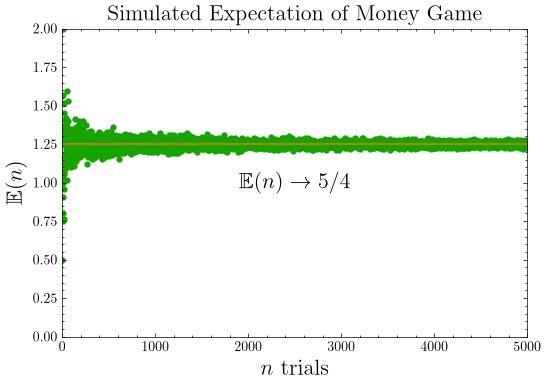

In [2]:
rng = np.random.default_rng(SEED)

c = 1
n = 5000

def runs(n): # creating vector of expectations
    # for each j = 1..n, play j games; each game doubles or halves c with probability 1/2
    return [np.mean(c*np.where(rng.integers(0, 2, size=j) == 1, 2, 0.5)) for j in range(1, n+1)]

plt.figure(figsize=(6,4))
plt.scatter(list(range(1,n+1)), runs(n), marker='.', color=C.green, linewidths=1.5)
plt.hlines(5/4, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5)
plt.text(n/2, 1, '$\mathbb{E}(n) \\rightarrow 5/4$', ha='center', va='center', fontsize=16)
plt.title('Simulated Expectation of Money Game', fontsize=16)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{E}(n)$', fontsize=16)
plt.xlim(0,n)
plt.ylim(0,2)
savefig(plt.gcf(), 'chap3ex1.eps', bbox_inches=None)
plt.show()

4. A particle starts at the origin of the real line and moves along the line in jumps of one unit. For each jump the probability is $p$ that the particle will jump one unit to the left and the probability is $1-p$ that the particle will jump one unit to the right. Let $X_n$ be the position of the particle after $n$ units. Find $\mathbb{E}(X_n)$ and $\mathbb{V}(X_n)$. (This is known as a **random walk**.)

Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex4i.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex4i.eps


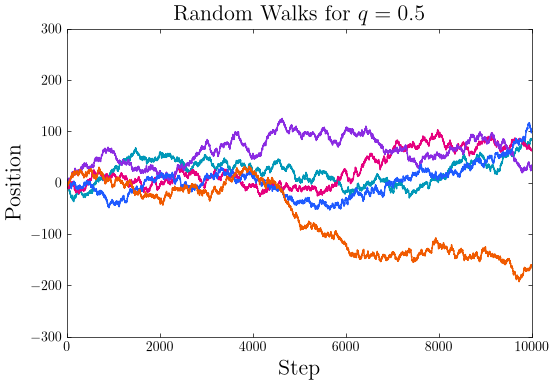

In [3]:
# functions for graphing the random walk
rng = np.random.default_rng(SEED)

q = 0.5 # probability

def multiplewalks(k,n): # k random walks of n steps: -1 with probability q, +1 with probability 1-q
    steps = rng.choice([-1, 1], size=(k, n), p=[q, 1-q])
    return np.cumsum(steps, axis=1)   # every position of every walk

k = 5
n = 10000
walks = multiplewalks(k,n)

plt.figure(figsize=(6,4))
plt.plot(list(range(1,n+1)), walks[0], color=C.cyan)
plt.plot(list(range(1,n+1)), walks[1], color=C.magenta)
plt.plot(list(range(1,n+1)), walks[2], color=C.violet)
plt.plot(list(range(1,n+1)), walks[3], color=C.blue)
plt.plot(list(range(1,n+1)), walks[4], color=C.orange)
plt.title('Random Walks for $q={}$'.format(q), fontsize=16)
plt.xlabel('Step', fontsize=16)
plt.ylabel('Position', fontsize=16)
plt.xlim(0,n)
plt.ylim(-300,300)
plt.minorticks_off()
savefig(plt.gcf(), 'chap3ex4i.eps', bbox_inches=None)
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\288545813.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.text(-250, 0.005, '$\mathbb{{E}}(n) = {}$'.format(round(e,2)), ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\288545813.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.text(250, 0.005, '$\mathbb{{V}}(n) = {}$'.format(round(v,2)), ha='center', va='center', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex4ii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex4ii.eps


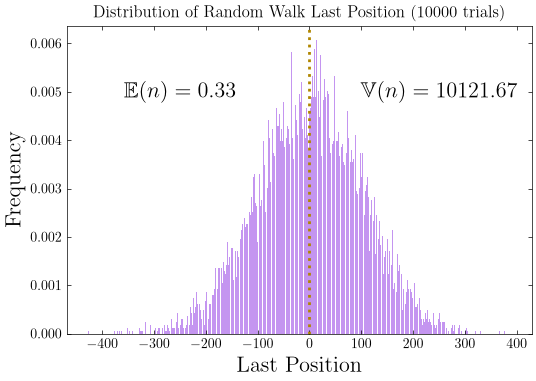

In [4]:
rng = np.random.default_rng(SEED)

def lastpositions(n, walks, chunk=1000): # last position of each of `walks` random walks of n steps
    out = []
    for start in range(0, walks, chunk):   # in chunks of 1000 walks, to bound memory
        steps = rng.choice([-1, 1], size=(min(chunk, walks - start), n), p=[q, 1-q])
        out.append(steps.sum(axis=1))
    return np.concatenate(out)

n = 10000
lastposition = lastpositions(n, n)

e = np.mean(lastposition)
v = np.var(lastposition, ddof=1)   # sample variance, as statistics.variance

plt.figure(figsize=(6,4))
count, bins, ignored = plt.hist(lastposition, 500, density=True, color=tint(C.violet))
plt.axvline(0, color=C.yellow, linestyle='dotted', linewidth=2, clip_on=False)
plt.title('Distribution of Random Walk Last Position ({} trials)'.format(n), fontsize=12)
plt.text(-250, 0.005, '$\mathbb{{E}}(n) = {}$'.format(round(e,2)), ha='center', va='center', fontsize=16)
plt.text(250, 0.005, '$\mathbb{{V}}(n) = {}$'.format(round(v,2)), ha='center', va='center', fontsize=16)
plt.xlabel('Last Position', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.minorticks_off()
savefig(plt.gcf(), 'chap3ex4ii.eps', bbox_inches=None)
plt.show()


5. A fair coin is tossed until a head is obtained. What is the expected number of tosses that will be required?

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\1163153916.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.text(n/2, 1.5, '$\mathbb{E}(n) \\rightarrow 2$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\1163153916.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbb{E}(n)$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex5.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex5.eps


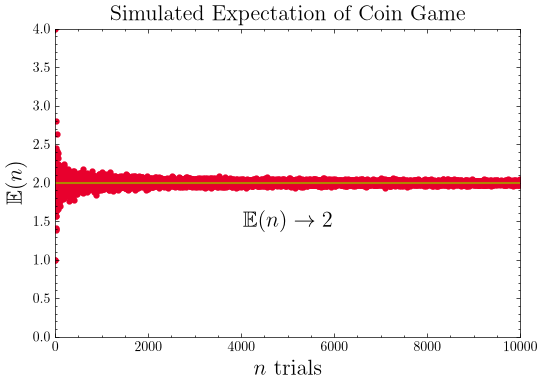

In [5]:
rng = np.random.default_rng(SEED)

def trials(n): # coin toss game over 1, ..., n trials
    # tosses up to and including the first head are Geometric(1/2); mean over i games, for each i
    return [rng.geometric(0.5, size=i).mean() for i in range(1, n+1)]

n = 10000

plt.figure(figsize=(6,4))
plt.scatter(list(range(1,n+1)), trials(n), marker='.', color=C.red, linewidths=1.5)
plt.hlines(2, 0, n, colors=C.yellow, linestyles='solid', linewidths=1.5)
plt.text(n/2, 1.5, '$\mathbb{E}(n) \\rightarrow 2$', ha='center', va='center', fontsize=16)
plt.title('Simulated Expectation of Coin Game', fontsize=16)
plt.xlabel('$n$ trials', fontsize=16)
plt.ylabel('$\mathbb{E}(n)$', fontsize=16)
plt.xlim(0,n)
plt.ylim(0,4)
savefig(plt.gcf(), 'chap3ex5.eps', bbox_inches=None)
plt.show()

9. (Computer Experiment.) Let $X_1, ..., X_n$ be $N(0,1)$ random variables and let $\overline{X}_n = n^{-1} \sum^n_{i=1} X_i$. Plot $\overline{X}_n$ versus $n$ for $n = 1, ..., 10,000$. Repeat for $X_1, X_2, ..., X_n \sim$ Cauchy. Explain why there is such a difference.

<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\o'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\1850714373.py:14: SyntaxWarning: invalid escape sequence '\o'
  axs[0].text(n/2, 0.2, '$\overline{X}_n \\rightarrow 0$', ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\1850714373.py:15: SyntaxWarning: invalid escape sequence '\s'
  axs[0].set_title('$X \sim N(0,1)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\1850714373.py:17: SyntaxWarning: invalid escape sequence '\o'
  axs

saved chap3ex9.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex9.eps


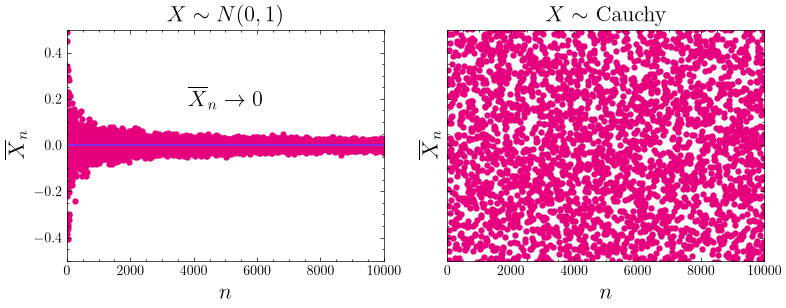

In [6]:
rng = np.random.default_rng(SEED)

def normal(n):
    return [rng.normal(0, 1, i).mean() for i in range(1, n+1)]

def cauchy(n):
    return [rng.standard_cauchy(i).mean() for i in range(1, n+1)]

n = 10000

fig, axs = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
axs[0].scatter(list(range(1,n+1)), normal(n), marker='.', color=C.magenta, linewidths=1.5)
axs[0].hlines(0, 0, n, colors=C.violet, linestyles='solid', linewidths=1.5)
axs[0].text(n/2, 0.2, '$\overline{X}_n \\rightarrow 0$', ha='center', va='center', fontsize=16)
axs[0].set_title('$X \sim N(0,1)$', fontsize=16)
axs[0].set_xlabel('$n$', fontsize=16)
axs[0].set_ylabel('$\overline{X}_n$', fontsize=16)
axs[0].set_xlim(0,n)
axs[0].set_ylim(-0.5,0.5)

axs[1].scatter(list(range(1,n+1)), cauchy(n), marker='.', color=C.magenta, linewidths=1.5)
axs[1].set_title('$X \sim$ Cauchy', fontsize=16)
axs[1].set_xlabel('$n$', fontsize=16)
axs[1].set_ylabel('$\overline{X}_n$', fontsize=16)
axs[1].set_xlim(0,n)
axs[1].set_ylim(-0.5,0.5)
savefig(plt.gcf(), 'chap3ex9.eps', bbox_inches=None)
plt.show()

10. Let $X \sim N(0,1)$ and let $Y = e^X$. Find $\mathbb{E}(Y)$ and $\mathbb{V}(Y)$.

<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\4049439660.py:14: SyntaxWarning: invalid escape sequence '\m'
  plt.text(7, 0.4, "$\mathbb{{E}}(\overline{{Y}}_n) = {} \\rightarrow e^{{1/2}}$".format(meany), ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\4049439660.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.text(7.3, 0.3, "$\mathbb{{V}}(\overline{{Y}}_n) = {} \\rightarrow e^2 - e$".format(vary), ha='center', va='center', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\4049439660.py:20: SyntaxWarning: invalid escape sequence '\m'
  plt.legend([expectation], ['$\mathbb{E}(Y)$'], loc= 'upper right', frameon=True, font

saved chap3ex10.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex10.eps


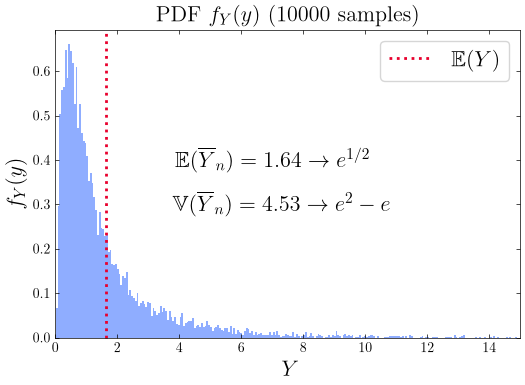

In [7]:
rng = np.random.default_rng(SEED)
n = 10000 # number of samples

x = rng.normal(0,1,n) # normal samples
y = np.exp(x) # exponential transformation
meany = round(np.mean(y),2)
vary = round(np.var(y, ddof=1),2)

plt.figure(figsize=(6,4))
count, bins, ignored = plt.hist(y, 1000, density=True, color=tint(C.blue))
expectation = plt.axvline(np.sqrt(np.e), color=C.red, linestyle='dotted', linewidth=2, clip_on=False)
plt.title('PDF $f_Y(y)$ ({} samples)'.format(n), fontsize=16)
#plt.text(7, 0.4, "\\begin{{eqnarray*}}\mathbb{{E}}(\overline{{Y}}_n)&=& {} \\rightarrow e^{{1/2}} \\\\ \mathbb{{V}}(\overline{{Y}}_n)&=& {} \\rightarrow e^2 - e \\end{{eqnarray*}}".format(meany, vary), ha='center', va='center', fontsize=16)
plt.text(7, 0.4, "$\mathbb{{E}}(\overline{{Y}}_n) = {} \\rightarrow e^{{1/2}}$".format(meany), ha='center', va='center', fontsize=16)
plt.text(7.3, 0.3, "$\mathbb{{V}}(\overline{{Y}}_n) = {} \\rightarrow e^2 - e$".format(vary), ha='center', va='center', fontsize=16)
plt.xlabel('$Y$', fontsize=16)
plt.ylabel('$f_Y(y)$', fontsize=16)
plt.xlim(0,15)
plt.minorticks_off()
plt.legend([expectation], ['$\mathbb{E}(Y)$'], loc= 'upper right', frameon=True, fontsize=16)
savefig(plt.gcf(), 'chap3ex10.eps', bbox_inches=None)
plt.show()

13. Suppose we generate a random variable $X$ in the following way. First we flip a fair coin. If the coin is heads, take $X$ to have a Unif $(0,1)$ distribution. If the coin is tails, take $X$ to  have a Unif $(3,4)$ distribution.

(a) Find the mean of $X$.

(b) Find the standard deviation of $X$.

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\1448767615.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.legend([expectation], ['$\mathbb{E}(X)$'], loc= 'upper right', frameon=True, fontsize=16)


The expected value is  2.001  and the standard deviation is  1.528


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex13.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex13.eps


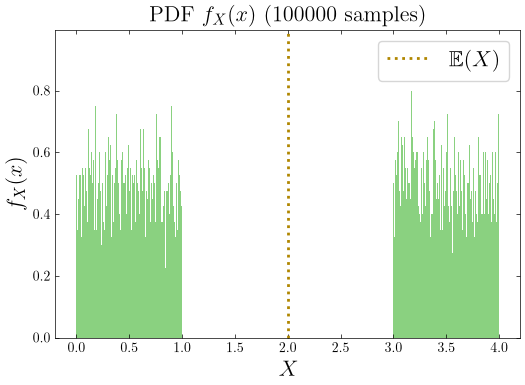

In [8]:
rng = np.random.default_rng(SEED)

def samples(n): # flip a fair coin; heads (0): X ~ Uniform(0,1), tails (1): X ~ Uniform(3,4)
    heads = rng.integers(0, 2, size=n) == 0
    return np.where(heads, rng.uniform(0, 1, n), rng.uniform(3, 4, n))

n = 100000
sample = samples(n)   # one sample for the mean, the standard deviation and the histogram

exp = round(np.mean(sample),3)
sd = round(np.sqrt(np.var(sample, ddof=1)),3)
print('The expected value is ', exp, ' and the standard deviation is ', sd)

plt.figure(figsize=(6,4))
count, bins, ignored = plt.hist(sample, 10000, density=True, color=tint(C.green))
expectation = plt.axvline(2, color=C.yellow, linestyle='dotted', linewidth=2, clip_on=False)
plt.title('PDF $f_X(x)$ ({} samples)'.format(n), fontsize=16)
plt.xlabel('$X$', fontsize=16)
plt.ylabel('$f_X(x)$', fontsize=16)
plt.minorticks_off()
plt.legend([expectation], ['$\mathbb{E}(X)$'], loc= 'upper right', frameon=True, fontsize=16)
savefig(plt.gcf(), 'chap3ex13.eps', bbox_inches=None)
plt.show()

19. This question is to help you understand the idea of a **sampling distribution**. Let $X_1, . . . , X_n$ be IID with mean $\mu$ and variance $\sigma^2$. Let $\overline{X}_n = n^{-1} \sum^n_{i=1} X_i$. Then $\overline{X}_n$ is a **statistic**, that is, a function of the data. Since $\overline{X}_n$ is a random variable, it has a distribution. This distribution is called the _sampling distribution of the statistic_. Recall from Theorem 3.17 that $\mathbb{E}(\overline{X}_n) = \mu$ and $\mathbb{V}(\overline{X}_n) = \sigma^2/n$. Don’t confuse the distribution of data $f_X$ and the distribution of the statistic $f_{\overline{X}_n}$. To make this clear, let $X_1, . . . , X_n \sim$ Uniform $(0, 1)$. Let $f_X$ be the density of the Uniform $(0,1)$. Plot $f_X$. Now let $\overline{X}_n = n^{-1} \sum^n_{i=1} X_i$. Find $\mathbb{E}(\overline{X}_n)$ and $\mathbb{V}(\overline{X}_n)$. Plot them as a function of $n$. Interpret. Now simulate the distribution of $\overline{X}_n$ for $n = 1, 5, 25, 100$. Check that the simulated values of $\mathbb{E}(\overline{X}_n)$ and $\mathbb{V}(\overline{X}_n)$ agree with your theoretical calculations. What do you notice about the sampling distribution of $X_n$ as $n$ increases?

Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex19i.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex19i.eps


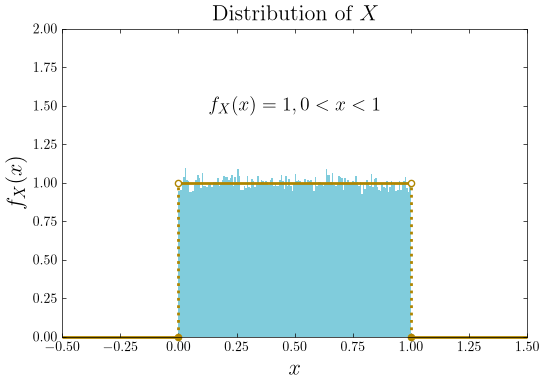

In [9]:
# plotting f_X

plt.figure(figsize=(6,4))

x_hollow, y_xhollow = [0,1], [1,1]
x_solid, y_xsolid = [0,1], [0,0]
h_xlines, x_start, x_end = [0, 0, 1], [-0.5, 1, 0], [0, 1.5, 1]
v_xlines, y_xstart, y_xend = [0,1], [0,0], [1,1]
rng = np.random.default_rng(SEED)
count, bins, ignored = plt.hist(rng.uniform(0, 1, 100000), 150, density=True, color=tint(C.cyan))
plt.scatter(x_hollow, y_xhollow, s=20, facecolors=BG, edgecolors=C.yellow, zorder=2, clip_on=False) # hollow points
plt.scatter(x_solid, y_xsolid, s=20, facecolors=C.yellow, edgecolors=C.yellow, zorder=2, clip_on=False) # solid points
plt.hlines(h_xlines, x_start, x_end, colors=C.yellow, linestyles='solid', linewidths=2, zorder=1, clip_on=False)
plt.vlines(v_xlines, y_xstart, y_xend, colors=C.yellow, linestyles='dotted', linewidths=2, zorder=1, clip_on=False)
plt.title('\\text{Distribution of} $X$', fontsize=16)
plt.xlabel('$x$', fontsize=16)
plt.ylabel('$f_X(x)$', fontsize=16)
plt.text(0.5, 1.5, '$f_X(x) = 1, 0 < x < 1$', ha='center', va='center', fontsize=14)
plt.xlim([-0.5, 1.5])
plt.ylim([0,2])
plt.minorticks_off()

savefig(plt.gcf(), 'chap3ex19i.eps', bbox_inches=None)
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\3450517756.py:32: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_title('$\mathbb{E}(\overline{X}_n)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\3450517756.py:34: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_ylabel('$\mathbb{E}(\overline{X}_n)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\3450517756.py:42: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title('$\mathbb{V}(\overline{X}_n)$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\3450517756.py

saved chap3ex19ii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex19ii.eps


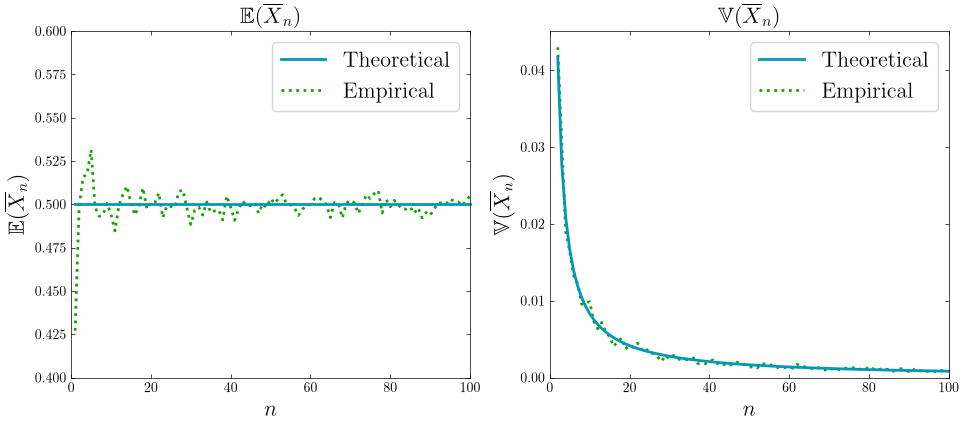

In [10]:
# plotting sample mean and variance

rng = np.random.default_rng(SEED)
n = 100 # number of variables
m = 100 # number of samples drawn from each variable
ne = list(range(1, n+1))
nv = list(range(2, n+1))

def xbarexp(n,m): # (num variables, num samples)
    means = []
    for i in range(1,n+1):
        means.append(rng.uniform(0,1,size=(m,i)).mean(axis=1).mean(axis=0)) # syntax: m is number of samples, i is number of variables
        # rng.uniform(0,1,size=(m,i)).mean(axis=1) contains values of Xbar_n for all m samples 
        # adding .mean(axis=0) then calculates the expectation of all of the m Xbar_n sample values for i number of variables
        # means.append adds the expectation for 1, 2, ..., n number of variables to our list
    return means; 

def xbarvar(n,m): # (num variables, num samples)
    vars = []
    for i in range(2,n+1):
        vars.append(rng.uniform(0,1,size=(m,i)).mean(axis=1).var(axis=0)) # syntax: m is number of samples, i is number of variables
        # rng.uniform(0,1,size=(m,i)).mean(axis=1) contains values of Xbar_n for all m samples 
        # adding .var(axis=0) then calculates the variance of all of the m Xbar_n sample values for i number of variables
        # vars.append adds the variances for 1, 2, ..., n number of variables to our list
    return vars; 

fig, axs = plt.subplots(1, 2, figsize=(9, 4.5), sharey=False)
plt.subplots_adjust(left=None, bottom=None, right=1.1, top=None, wspace=None, hspace=None)

axs[0].plot(ne, [1/2]*len(ne), color=C.cyan, linewidth=2, zorder=2, clip_on=False, label='Theoretical')
axs[0].plot(ne,xbarexp(n,m), color=C.green, linestyle='dotted', linewidth=2, zorder=1, clip_on=False, label='Empirical')
axs[0].set_title('$\mathbb{E}(\overline{X}_n)$', fontsize=16)
axs[0].set_xlabel('$n$', fontsize=16)
axs[0].set_ylabel('$\mathbb{E}(\overline{X}_n)$', fontsize=16)
axs[0].set_xlim([0,n])
axs[0].set_ylim([0.4,0.6])
axs[0].legend(loc= 'upper right', frameon=True, fontsize=16)
axs[0].minorticks_off()

axs[1].plot(nv, [1/(12*i) for i in nv], color=C.cyan, linewidth=2, zorder=2, clip_on=False, label='Theoretical')
axs[1].plot(nv,xbarvar(n,m), color=C.green, linestyle='dotted', linewidth=2, zorder=1, clip_on=False, label='Empirical')
axs[1].set_title('$\mathbb{V}(\overline{X}_n)$', fontsize=16)
axs[1].set_xlabel('$n$', fontsize=16)
axs[1].set_ylabel('$\mathbb{V}(\overline{X}_n)$', fontsize=16)
axs[1].set_xlim([0,n])
axs[1].set_ylim(0)
axs[1].legend(loc= 'upper right', frameon=True, fontsize=16)
axs[1].minorticks_off()

savefig(plt.gcf(), 'chap3ex19ii.eps', bbox_inches=None)
plt.show()


<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:28: SyntaxWarning: invalid escape sequence '\o'
C:\Users\david\AppData\Local\Temp\ipykernel_18676\878386876.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\overline{X}_n$', fontsize=16)
C:\Users\david\AppData\Local\Temp\ipykernel_18676\878386876.py:28: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('$f_{\overline{X}_n}$', fontsize=16)
Failed to find a Ghostscript installation.  Distillation step skipped.


saved chap3ex19iii.eps -> \\wsl.localhost\Ubuntu-22.04\home\cantorian_infinity\math\allofstats\chap3\chap3ex19iii.eps


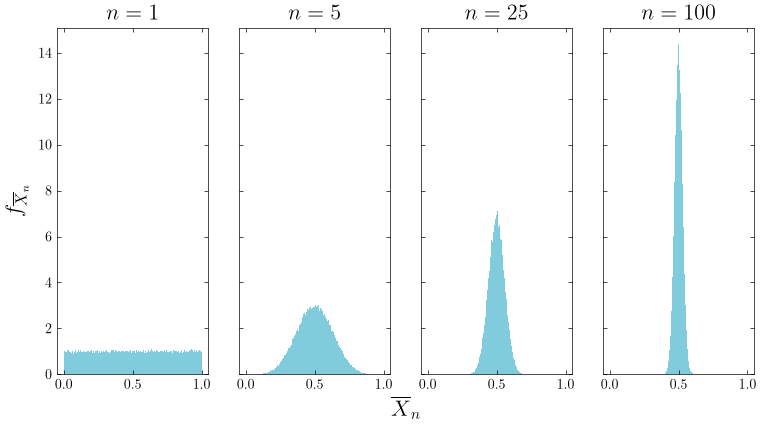

In [11]:
# plotting distributions of Xbar_n

rng = np.random.default_rng(SEED)
m = 1000000 # number of samples
n1, n2, n3, n4 = 1,5,25,100 # number of variables
variables = [n1, n2, n3, n4]

def xbar(n, m, chunk=100000): # (num variables, num samples)
    # m samples of Xbar_n for n variables, drawn 100000 rows at a time to bound memory
    return np.concatenate([rng.uniform(0, 1, size=(min(chunk, m - s), n)).mean(axis=1)
                           for s in range(0, m, chunk)])

fig, axs = plt.subplots(1, 4, figsize=(9, 4.5), sharey=True, sharex=True)
#plt.subplots_adjust(left=None, bottom=None, right=2, top=None, wspace=None, hspace=None)

for ax, variable in zip(axs.flat, variables):
    count, bins, ignored = ax.hist(xbar(variable,m), 1500, density=True, color=tint(C.cyan))
    ax.set_title('$n = {}$'.format(variable), fontsize=16)
    ax.minorticks_off()    

# big axes for common label
fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
plt.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
plt.grid(False)
plt.minorticks_off()
plt.xlabel('$\overline{X}_n$', fontsize=16)
plt.ylabel('$f_{\overline{X}_n}$', fontsize=16)

savefig(plt.gcf(), 'chap3ex19iii.eps', bbox_inches=None)
plt.show()